In [20]:
import numpy as np
import matplotlib.pyplot as plt

from torch import multiprocessing
from pathlib import Path

import re

In [21]:
ram_options = np.array([6, 15, 30, 60, 125, 250])

In [26]:
sorted(list(Path(f'').glob('2024*baseline*estimates.npy')))

[PosixPath('20241107__large_160gb_baseline_16p1c1t_estimates.npy'),
 PosixPath('20241107__medium_160gb_baseline_8p1c1t_estimates.npy'),
 PosixPath('20241108__quad_160gb_baseline_4p1c1t_estimates.npy'),
 PosixPath('20241108__small_160gb_baseline_2p1c1t_estimates.npy'),
 PosixPath('20241108__xl_160gb_baseline_32p1c1t_estimates.npy'),
 PosixPath('20241109__2xl_160gb_baseline_64p1c1t_estimates.npy')]

In [42]:
sorted(list(Path(f'').glob('2024*parallel*estimates.npy')))

[PosixPath('20241107__large_160gb_parallel_16p1c1t_estimates.npy'),
 PosixPath('20241108__2xl_160gb_parallel_64p1c1t_estimates.npy'),
 PosixPath('20241108__medium_160gb_parallel_8p1c1t_estimates.npy'),
 PosixPath('20241108__quad_160gb_parallel_4p1c1t_estimates.npy'),
 PosixPath('20241108__small_160gb_parallel_2p1c1t_estimates.npy'),
 PosixPath('20241108__xl_160gb_parallel_32p1c1t_estimates.npy')]

In [28]:
baseline_estimates = np.zeros((6, 3))
i=0
for path_est in sorted(list(Path(f'').glob('2024*baseline*estimates.npy'))):
    baseline_estimates[i]=np.load(path_est)
    i+=1
baseline_estimates

array([[ 2826.17740822, 19595.01978588, 22421.1971941 ],
       [ 2976.29775167, 26318.09190679, 29294.38965845],
       [ 2982.24060202, 31313.79905748, 34296.0396595 ],
       [ 2877.00982022, 51275.27165246, 54152.28147268],
       [ 3074.38129377, 22271.73245764, 25346.11375141],
       [ 3295.1599288 , 26517.03689957, 29812.19682837]])

In [33]:
baseline_estimates = np.zeros((6, 3))
for path_est in sorted(list(Path(f'').glob('2024*baseline*estimates.npy'))):
    match = re.search(r'_(\d+)p', path_est.name)

    num_processes = int(match.group(1))
    index = int(np.log2(num_processes)) - 1
    baseline_estimates[index]=np.load(path_est)
baseline_estimates

array([[ 2877.00982022, 51275.27165246, 54152.28147268],
       [ 2982.24060202, 31313.79905748, 34296.0396595 ],
       [ 2976.29775167, 26318.09190679, 29294.38965845],
       [ 2826.17740822, 19595.01978588, 22421.1971941 ],
       [ 3074.38129377, 22271.73245764, 25346.11375141],
       [ 3295.1599288 , 26517.03689957, 29812.19682837]])

In [43]:
parallel_estimates = np.zeros((6, 3))
for path_est in sorted(list(Path(f'').glob('2024*parallel*estimates.npy'))):
    match = re.search(r'_(\d+)p', path_est.name)

    num_processes = int(match.group(1))
    index = int(np.log2(num_processes)) - 1
    parallel_estimates[index]=np.load(path_est)
parallel_estimates

array([[ 1570.67969942, 43092.42247057, 44663.10216999],
       [  776.64884973, 20914.41994524, 21691.06879497],
       [  396.23534489, 10348.91966772, 10745.15501261],
       [  219.56020689,  5584.40352035,  5803.96372724],
       [  153.14333868,  3411.48077703,  3564.62411571],
       [  210.69393396,  2881.70358133,  3092.3975153 ]])

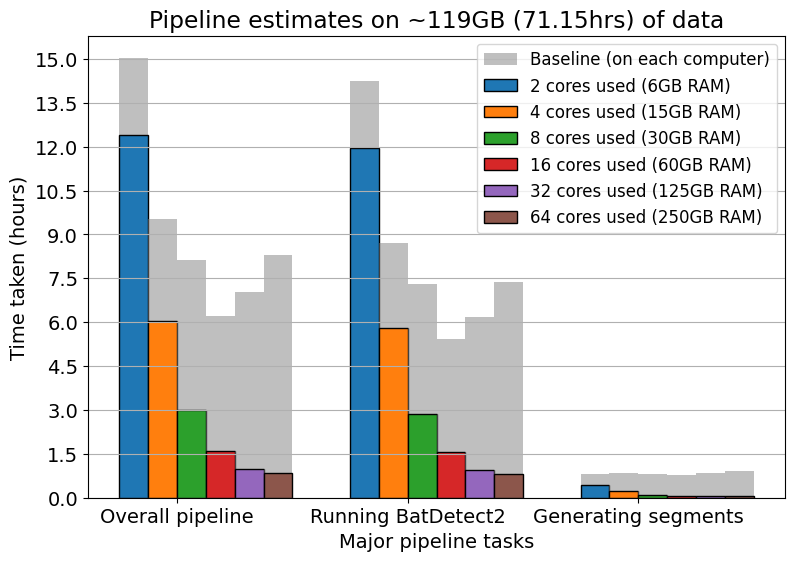

In [35]:
plt.figure(figsize=(9,6))
plt.rcParams.update({'font.size':14})
plt.title(f'Pipeline estimates on ~119GB (71.15hrs) of data')
line_labs = ['Baseline']
bin_wdth = 0.125
offset = (parallel_estimates.shape[0]/2)*bin_wdth - (bin_wdth/2)
time_fac = 1/3600

for i in range(baseline_estimates.shape[0]):
    baseline_times_taken = baseline_estimates[i,::-1]*time_fac
    if i==0:
        plt.bar(x=np.arange(3)+offset+(i*bin_wdth), height=baseline_times_taken, width=bin_wdth, color='grey', 
                alpha=0.5, label=f'Baseline (on each computer)')
    else:
        plt.bar(x=np.arange(3)+offset+(i*bin_wdth), height=baseline_times_taken, width=bin_wdth, color='grey', alpha=0.5)
    parallel_times_taken = parallel_estimates[i,::-1]*time_fac
    plt.bar(x=np.arange(3)+offset+((i)*bin_wdth), height=parallel_times_taken, width=bin_wdth, 
            label=f'{2**(i+1)} cores used ({ram_options[i]}GB RAM)', edgecolor='k')
    plt.xticks(ticks=np.arange(3)+0.5, labels=['Generating segments', 'Running BatDetect2', 'Overall pipeline'][::-1])

plt.xlabel('Major pipeline tasks')
plt.ylabel('Time taken (hours)')
plt.yticks(np.linspace(0, 15*3600, 11)*time_fac)
plt.legend(ncols=1, loc='upper right', fontsize=12)
plt.grid(axis='y')
plt.show()

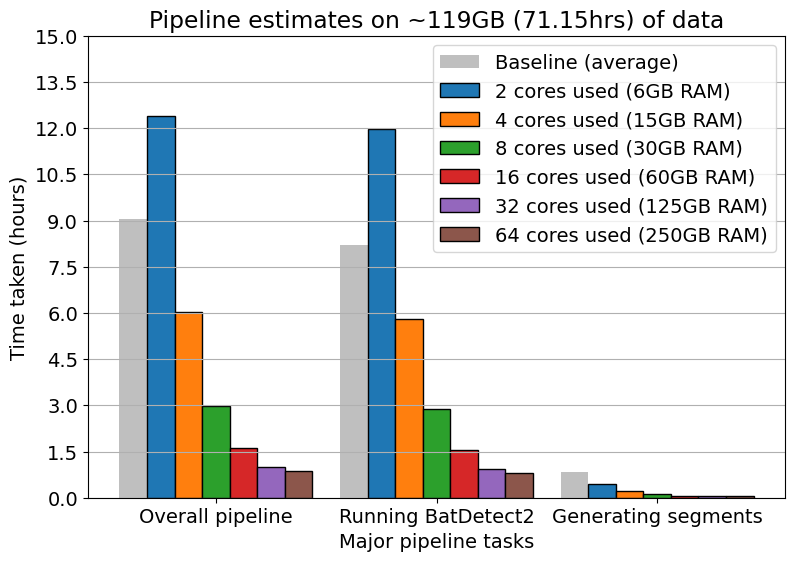

In [36]:
plt.figure(figsize=(9,6))
plt.rcParams.update({'font.size':14})
plt.title(f'Pipeline estimates on ~119GB (71.15hrs) of data')
line_labs = ['Baseline']
bin_wdth = 0.125
offset = (parallel_estimates.shape[0]/2)*2*bin_wdth - 4*(bin_wdth)
time_fac = 1/3600
baseline_times_taken = np.mean(baseline_estimates[:,::-1]*time_fac, axis=0)
plt.bar(x=np.arange(3)+offset-(bin_wdth), height=baseline_times_taken, width=bin_wdth, color='grey', 
            alpha=0.5, label=f'Baseline (average)')

for i in range(parallel_estimates.shape[0]):
    parallel_times_taken = parallel_estimates[i,::-1]*time_fac
    plt.bar(x=np.arange(3)+offset+((i)*bin_wdth), height=parallel_times_taken, width=bin_wdth, 
            label=f'{2**(i+1)} cores used ({ram_options[i]}GB RAM)', edgecolor='k')
    plt.xticks(ticks=np.arange(3)+0.5, labels=['Generating segments', 'Running BatDetect2', 'Overall pipeline'][::-1])

plt.xlabel('Major pipeline tasks')
plt.ylabel('Time taken (hours)')
plt.yticks(np.linspace(0, 15*3600, 11)*time_fac)
plt.legend(ncols=1, loc='upper right', fontsize=14)
plt.grid(axis='y')
plt.show()

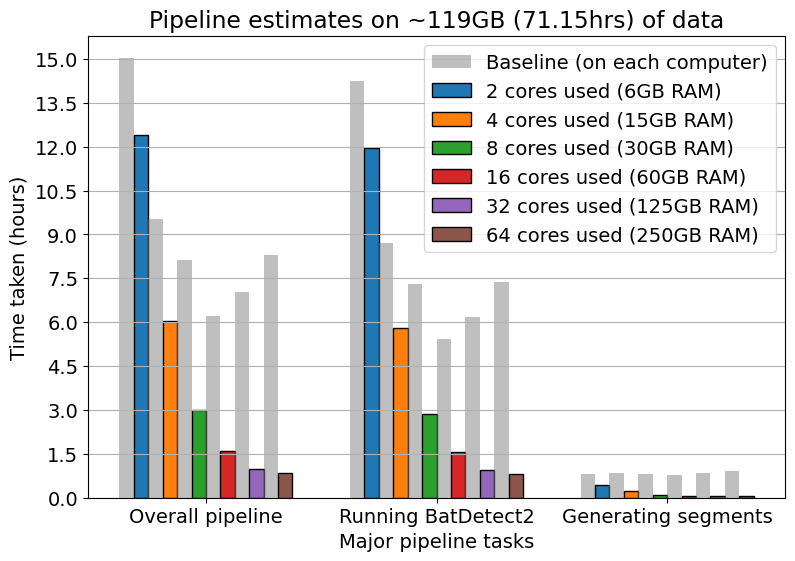

In [40]:
plt.figure(figsize=(9,6))
plt.rcParams.update({'font.size':14})
plt.title(f'Pipeline estimates on ~119GB (71.15hrs) of data')
line_labs = ['Baseline']
bin_wdth = 0.125/2
offset = (parallel_estimates.shape[0]/2)*2*bin_wdth - 3.5*(bin_wdth)
time_fac = 1/3600

for i in range(baseline_estimates.shape[0]):
    baseline_times_taken = baseline_estimates[i,::-1]*time_fac
    if i==0:
        plt.bar(x=np.arange(3)+offset+(2*i*bin_wdth), height=baseline_times_taken, width=bin_wdth, color='grey', 
                alpha=0.5, label=f'Baseline (on each computer)')
    else:
        plt.bar(x=np.arange(3)+offset+(2*i*bin_wdth), height=baseline_times_taken, width=bin_wdth, color='grey', alpha=0.5)
    parallel_times_taken = parallel_estimates[i,::-1]*time_fac
    plt.bar(x=np.arange(3)+offset+(2*(i+0.5)*bin_wdth), height=parallel_times_taken, width=bin_wdth, 
            label=f'{2**(i+1)} cores used ({ram_options[i]}GB RAM)', edgecolor='k')
    plt.xticks(ticks=np.arange(3)+0.5, labels=['Generating segments', 'Running BatDetect2', 'Overall pipeline'][::-1])

plt.xlabel('Major pipeline tasks')
plt.ylabel('Time taken (hours)')
plt.yticks(np.linspace(0, 15*3600, 11)*time_fac)
plt.legend(ncols=1, loc='upper right', fontsize=14)
plt.grid(axis='y')
plt.show()

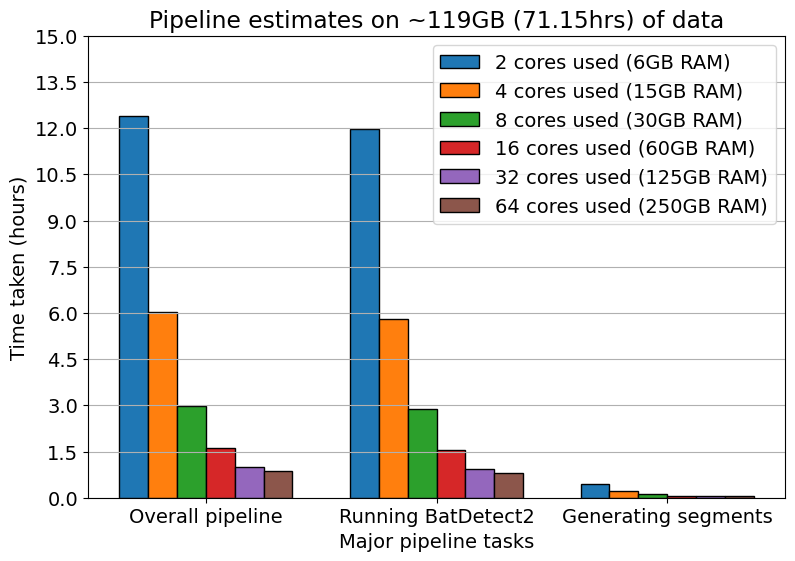

In [110]:
plt.figure(figsize=(9,6))
plt.rcParams.update({'font.size':14})
plt.title(f'Pipeline estimates on ~119GB (71.15hrs) of data')
line_labs = ['Baseline']
bin_wdth = 0.125
offset = (parallel_estimates.shape[0]/2)*2*bin_wdth - 4.5*(bin_wdth)
time_fac = 1/3600

for i in range(parallel_estimates.shape[0]):
    parallel_times_taken = parallel_estimates[i,::-1]*time_fac
    plt.bar(x=np.arange(3)+offset+(i*bin_wdth), height=parallel_times_taken, width=bin_wdth, 
            label=f'{2**(i+1)} cores used ({ram_options[i]}GB RAM)', edgecolor='k')
    plt.xticks(ticks=np.arange(3)+0.5, labels=['Generating segments', 'Running BatDetect2', 'Overall pipeline'][::-1])

plt.xlabel('Major pipeline tasks')
plt.ylabel('Time taken (hours)')
plt.yticks(np.linspace(0, 15*3600, 11)*time_fac)
plt.legend(ncols=1, loc='upper right', fontsize=14)
plt.grid(axis='y')
plt.show()

In [ ]:
plt.figure(figsize=(10,6))
plt.rcParams.update({'font.size':14})
plt.title(f'Pipeline estimates on ~119GB (71.15hrs) of data')
line_labs = ['Baseline']
bin_wdth = 0.125
offset = (parallel_estimates.shape[0]/2)*2*bin_wdth - 4.5*(bin_wdth)
time_fac = 1/3600

for i in range(parallel_estimates.shape[0]):
    parallel_times_taken = parallel_estimates[i,::-1]*time_fac
    plt.bar(x=np.arange(3)+offset+(i*bin_wdth), height=parallel_times_taken, width=bin_wdth, 
            label=f'{2**(i+1)} cores used ({ram_options[i]}GB RAM)', edgecolor='k')
    plt.xticks(ticks=np.arange(3)+0.5, labels=['Generating segments', 'Running BatDetect2', 'Overall pipeline'][::-1])

plt.xlabel('Major pipeline tasks')
plt.ylabel('Time taken (hours)')
plt.yticks(np.linspace(0, 15*3600, 11)*time_fac)
plt.legend(ncols=1, loc='upper right', fontsize=14)
plt.grid(which='both', axis='y')
plt.yscale('log')
plt.yticks(np.concatenate([np.arange(0.5, 1.01, 0.1), 10*np.arange(0.2, 1.01, 0.1)]).round(1), 
           np.concatenate([np.arange(0.5, 1.01, 0.1).round(1), (10*np.arange(0.2, 1.01, 0.1)).astype(int)]))
plt.ylim([0.5, 15])
plt.show()

array([  0.2,   0.3,   0.4,   0.5,   0.6,   0.7,   0.8,   0.9,   1. ,
         2. ,   3. ,   4. ,   5. ,   6. ,   7. ,   8. ,   9. ,  10. ,
        20. ,  30. ,  40. ,  50. ,  60. ,  70. ,  80. ,  90. , 100. ])

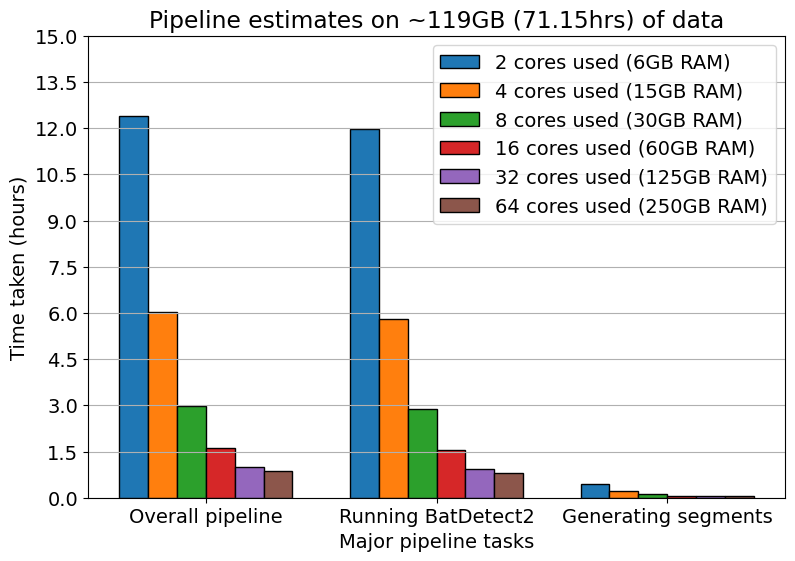

In [41]:
plt.figure(figsize=(9,6))
plt.rcParams.update({'font.size':14})
plt.title(f'Pipeline estimates on ~119GB (71.15hrs) of data')
line_labs = ['Baseline']
bin_wdth = 0.125
offset = (parallel_estimates.shape[0]/2)*2*bin_wdth - 4.5*(bin_wdth)
time_fac = 1/3600

for i in range(parallel_estimates.shape[0]):
    parallel_times_taken = parallel_estimates[i,::-1]*time_fac
    plt.bar(x=np.arange(3)+offset+(i*bin_wdth), height=parallel_times_taken, width=bin_wdth, 
            label=f'{2**(i+1)} cores used ({ram_options[i]}GB RAM)', edgecolor='k')
    plt.xticks(ticks=np.arange(3)+0.5, labels=['Generating segments', 'Running BatDetect2', 'Overall pipeline'][::-1])

plt.xlabel('Major pipeline tasks')
plt.ylabel('Time taken (hours)')
plt.yticks(np.linspace(0, 15*3600, 11)*time_fac)
plt.legend(ncols=1, loc='upper right', fontsize=14)
plt.grid(axis='y')
plt.show()

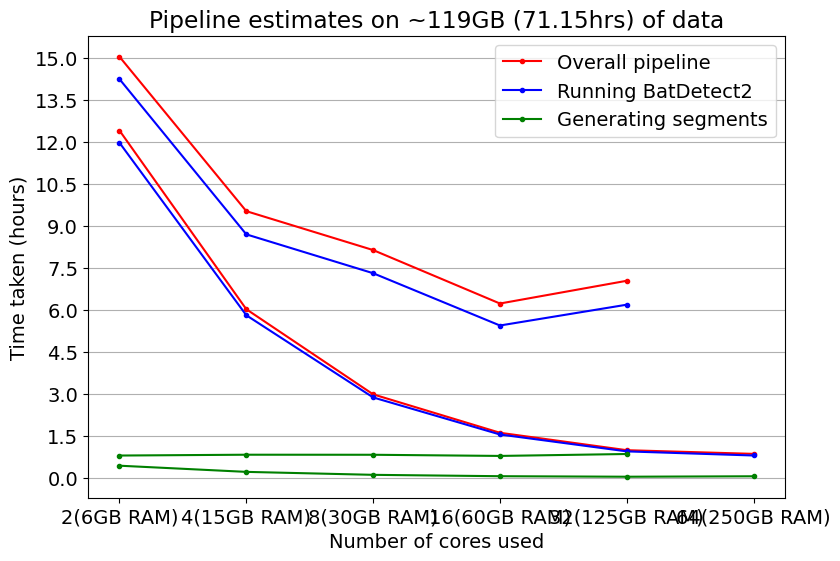

In [19]:
plt.figure(figsize=(9,6))
plt.rcParams.update({'font.size':14})
plt.title(f'Pipeline estimates on ~119GB (71.15hrs) of data')
line_labs = ['Baseline']
bin_wdth = 0.125
offset = (parallel_estimates.shape[0]/2)*2*bin_wdth - 3*(bin_wdth)
time_fac = 1/3600
x_labs = []
for i in range(parallel_estimates.shape[0]):
   x_labs+=[f'{2**(i+1)}({ram_options[i]}GB RAM)']

task_labs = ['Generating segments', 'Running BatDetect2', 'Overall pipeline'][::-1]
colors = ['red', 'blue', 'green']
plt.xticks(ticks=np.arange(len(x_labs)), labels=x_labs)
j = 2
for i in np.arange(0, 3):
    plt.plot(parallel_estimates[:,j]*time_fac, marker='.', color=colors[i])
    plt.plot(baseline_estimates[:,j]*time_fac, marker='.', color=colors[i], label=task_labs[i])
    j+= -1

plt.xlabel('Number of cores used')
plt.ylabel('Time taken (hours)')
plt.yticks(np.linspace(0, 15*3600, 11)*time_fac)
plt.legend(ncols=1, loc='upper right', fontsize=14)
plt.grid(axis='y')
plt.show()

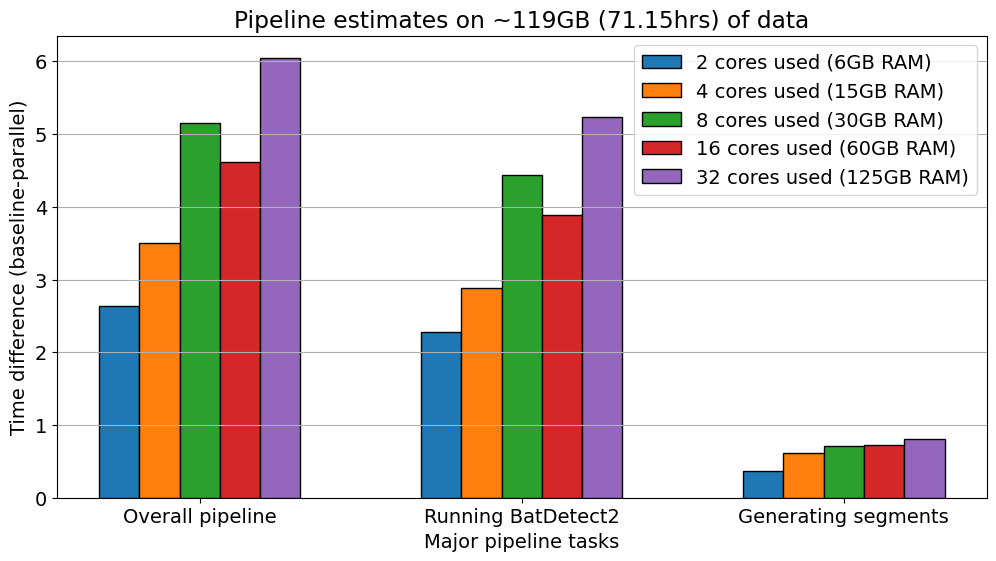

In [274]:
plt.figure(figsize=(12,6))
plt.rcParams.update({'font.size':14})
plt.title(f'Pipeline estimates on ~119GB (71.15hrs) of data')
line_labs = ['Baseline']
bin_wdth = 0.125
offset = (parallel_estimates.shape[0]/2)*bin_wdth - bin_wdth/2
time_fac = 1/3600

for i in range(baseline_estimates.shape[0]):
    baseline_times_taken = baseline_estimates[i,::-1]*time_fac
    parallel_times_taken = parallel_estimates[i,::-1]*time_fac

    plt.bar(x=np.arange(3)+offset+(i*bin_wdth), height=(baseline_times_taken-parallel_times_taken), width=bin_wdth, 
            alpha=1, label=f'{2**(i+1)} cores used ({ram_options[i]}GB RAM)', edgecolor='k')
    plt.xticks(ticks=np.arange(3)+0.5, labels=['Generating segments', 'Running BatDetect2', 'Overall pipeline'][::-1])

plt.xlabel('Major pipeline tasks')
plt.ylabel('Time difference (baseline-parallel)')
plt.legend(ncols=1, loc='upper right', fontsize=14)
plt.grid(axis='y')
plt.show()

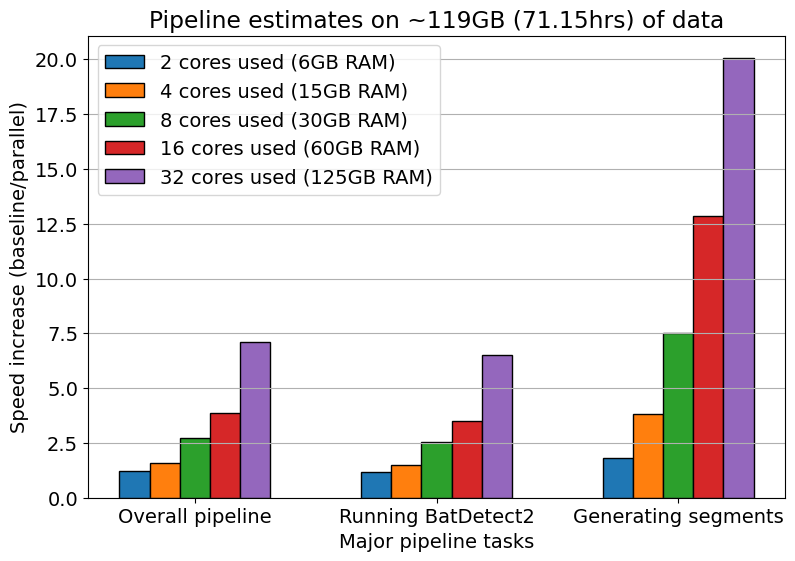

In [275]:
plt.figure(figsize=(9,6))
plt.rcParams.update({'font.size':14})
plt.title(f'Pipeline estimates on ~119GB (71.15hrs) of data')
line_labs = ['Baseline']
bin_wdth = 0.125
offset = (parallel_estimates.shape[0]/2)*bin_wdth - bin_wdth/2
time_fac = 1/3600

for i in range(baseline_estimates.shape[0]):
    baseline_times_taken = baseline_estimates[i,::-1]*time_fac
    parallel_times_taken = parallel_estimates[i,::-1]*time_fac

    plt.bar(x=np.arange(3)+offset+(i*bin_wdth), height=(baseline_times_taken/parallel_times_taken), width=bin_wdth, 
            alpha=1, label=f'{2**(i+1)} cores used ({ram_options[i]}GB RAM)', edgecolor='k')
    plt.xticks(ticks=np.arange(3)+0.5, labels=['Generating segments', 'Running BatDetect2', 'Overall pipeline'][::-1])

plt.xlabel('Major pipeline tasks')
plt.ylabel('Speed increase (baseline/parallel)')
plt.legend(ncols=1, loc='upper left', fontsize=14)
plt.grid(axis='y')
plt.show()